In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch,Rectangle
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import multiprocess as mp
import networkx as nx
from multiprocess import Process

# Import the MDP environment from causalAIgym
from causal_gym.envs.mdp_example import MDPExampleSCM, MDPExamplePCH
from causal_gym.envs.dtr_example import DTRExampleSCM, DTRExamplePCH
from causal_gym.core import PolicyType, ActType, ObsType
from utilities import run_episode, evaluate_policy, collect_observational_data_mdp, collect_interventional_data_mdp
from utilities import always_zero_policy, always_one_policy, match_state_policy, opposite_state_policy

## Background: Structural Causal Models and MDPs

Structural Causal Models (SCMs) provide a formal language for describing causal relationships. An SCM consists of:

- Exogenous (unobserved) variables $U$
- Endogenous (observed) variables $V$
- A set of structural functions $F$ that determine the values of endogenous variables
- A probability distribution $P(U)$ over the exogenous variables

In the context of MDPs, we can define:

- States $S$ and actions $X$ as endogenous variables
- Rewards $Y$ as functions of states and actions
- The transition dynamics as structural functions

# Example 8.5: MDP Planning with Dynamic Programming

This notebook implements Example 8.5 from Chapter 8 of the Causal Reinforcement Learning book. This example focuses on solving an MDP using dynamic programming to find the optimal policy in a causal reinforcement learning setting.

In Example 8.5, we consider the MDP environment defined by Equation 7.4, which models an inventory control problem. The key components include:

- Binary state $S_i$ representing inventory level (0=empty, 1=full)
- Binary action $X_i$ representing the decision to restock or not
- Reward $Y_i$ based on the state and action
- Exogenous variables $U_{i,1}, U_{i,2}, U_{i,3}$ representing operation errors, customer demand, and price fluctuations

The structural causal model is defined as:

$$
F_i = \begin{cases}
S_i \gets (S_{i-1} \vee X_{i-1}) \oplus U_{i-1,1} \oplus U_{i-1,2}, \\
X_i \gets S_i \oplus U_{i,1}, \\
Y_i \gets S_i \oplus X_i \oplus U_{i,1} \oplus U_{i,3}
\end{cases}
$$

Our goal is to find the optimal policy using dynamic programming and verify the results against theoretical expectations.

In [20]:
# Set discount factor as per Example 8.5
GAMMA = 0.9
# Maximum number of steps per episode
MAX_STEPS = 1000
# Number of samples for each experiment
N_SAMPLES = 2000

## 1. Implementing the MDP Environment

First, let's explore the MDP environment from the causalgym. The implementation follows the SCM defined in Example 8.5. We'll create functions to run episodes with different policies."
   

In [21]:
from utilities import run_episode
from utilities import evaluate_policy

## 2. Defining Different Policies

We'll define several policies to evaluate and compare:

1. **Always choose X=0**: Never restock regardless of state
2. **Always choose X=1**: Always restock regardless of state
3. **Match state policy (X=S)**: Restock only when inventory is full (this is the optimal policy according to Example 8.5)
4. **Opposite state policy (X≠S)**: Restock only when inventory is empty

In [22]:
# Define different policies for evaluation
def always_zero_policy(state):
    return 0

def always_one_policy(state):
    return 1

def match_state_policy(state):
    return state

def opposite_state_policy(state):
    return 1 - state

## 3. Evaluating Policies

We'll evaluate each policy by running multiple episodes and computing the average rewards

This function employs parallelization to efficiently evaluate any custom policy by running multiple simulation episodes simultaneously. It creates separate processes to run independent episodes, collects the results, and aggregates statistics (average rewards, standard deviations, etc.).
The function leverages multiprocessing to speed up policy evaluation, which is particularly valuable when:

- Evaluating multiple candidate policies
- Working with stochastic environments that require many samples for reliable estimates
- Comparing empirical performance against theoretical predictions

This implementation represents intervention in the environment (Layer 2 of the PCH) where we actively apply different policies and measure their performance, allowing us to make causal claims about which policy leads to the best outcomes.

In [23]:
# Evaluate each policy
policy_evaluations = [
    evaluate_policy(always_zero_policy, "do(X=0)"),
    evaluate_policy(always_one_policy, "do(X=1)"),
    evaluate_policy(match_state_policy, "do(X=S)"),
    evaluate_policy(opposite_state_policy, "do(X≠S)")
]

# Also evaluate the behavioral policy
manager = mp.Manager()
results = manager.list()
processes = []
for i in range(N_SAMPLES):
    p = Process(target=lambda: results.append(run_episode(seed=i)))
    processes.append(p)
    p.start()
for p in tqdm(processes, desc="Evaluating behavioral policy"):
    p.join()
behavioral_rewards = []
behavioral_daily_profits = []
for result in results:
    discounted_reward, _, _, rewards = result
    behavioral_rewards.append(discounted_reward)
    behavioral_daily_profits.extend(rewards)
behavioral_evaluation = {
    'name': "Behavioral Policy",
    'mean_reward': np.mean(behavioral_rewards),
    'std_reward': np.std(behavioral_rewards),
    'daily_profit': np.mean(behavioral_daily_profits),
    'rewards': behavioral_rewards,
    'daily_profits': behavioral_daily_profits
}
policy_evaluations.append(behavioral_evaluation)

Evaluating behavioral policy: 100%|██████████| 2000/2000 [00:00<00:00, 2066.94it/s] 


## 4. Displaying Results

Let's display the results of our policy evaluations compared with the theoretical expectations from Example 8.5.

In [24]:
# Print results for each policy
print("Results for Different Policy Interventions:")
print("-----------------------------------------------------")
print(f"{'Policy':<20} {'Daily Profit':<15} {'Discounted Reward':<20}")
print("-----------------------------------------------------")

# Theoretical values from Example 8.5
theoretical_values = {
    "do(X=S)": {"daily": 0.82, "cumulative": 8.2},
    "Behavioral Policy": {"daily": 0.1, "cumulative": 1.0}
}

# Sort policies by discounted reward (highest first)
sorted_evaluations = sorted(policy_evaluations, key=lambda x: x['mean_reward'], reverse=True)
for eval_data in sorted_evaluations:
    policy_name = eval_data['name']
    daily_profit = eval_data['daily_profit']
    discounted_reward = eval_data['mean_reward']
    
    # Check if we have theoretical values for this policy
    theoretical_str = ""
    if policy_name in theoretical_values:
        theoretical_daily = theoretical_values[policy_name]["daily"]
        theoretical_cum = theoretical_values[policy_name]["cumulative"]
        theoretical_str = f"(Expected: {theoretical_daily:.2f}, {theoretical_cum:.1f})"
    
    print(f"{policy_name:<20} {daily_profit:.4f} {discounted_reward:.4f} {theoretical_str}")

Results for Different Policy Interventions:
-----------------------------------------------------
Policy               Daily Profit    Discounted Reward   
-----------------------------------------------------
do(X=S)              0.8201 8.1667 (Expected: 0.82, 8.2)
do(X=0)              0.5000 4.9973 
do(X=1)              0.2952 3.0123 
do(X≠S)              0.1799 1.8333 
Behavioral Policy    0.1000 0.9931 (Expected: 0.10, 1.0)


## 5. Implementing the Q-Function Calculation

Now let's implement the Q-function calculation using dynamic programming as described in Example 8.5. According to the Bellman equation, the Q-function for state-action pairs is:

$$Q^*(s, a) = R_{exp}(s, a) + \gamma \sum_{s'} T_{exp}(s, a, s') \max_{a'} Q^*(s', a')$$

where:
- $R_{exp}(s, a)$ is the expected reward in state $s$ taking action $a$
- $T_{exp}(s, a, s')$ is the transition probability from state $s$ to $s'$ given action $a$
- $\gamma$ is the discount factor (0.9 in this example)

The transition probabilities and rewards are given in Figure 7.6 in the text

#### value_iteration:
Implements dynamic programming value iteration to compute the optimal Q-function. Iteratively applies the Bellman equation until convergence:
$$
Q(s,a) = R(s,a) + γ * Σ_s' P(s'|s,a) * max_a' Q(s',a')
$$
Parameters control discount factor (gamma=0.9), convergence criteria, and iteration limits. Returns the converged Q-values that determine the optimal action for each state

In [26]:
# Modified value iteration to use collected transition data
def value_iteration(transition_probs, expected_rewards, gamma=0.9, threshold=1e-10, max_iterations=1000):
    """
    Compute the optimal Q-function using value iteration with collected data.
    
    Args:
        transition_probs: [s, a, s'] transition probabilities
        expected_rewards: [s, a] expected rewards
        gamma: discount factor
        threshold: convergence threshold
        max_iterations: maximum number of iterations
        
    Returns:
        Q: optimal Q-function
    """
    # Initialize Q-values
    Q = np.zeros((2, 2))  # Q[s, a]
    iterations = 0
    
    while iterations < max_iterations:
        delta = 0
        old_Q = Q.copy()
        
        # Update Q-values for all state-action pairs
        for s in range(2):
            for a in range(2):
                # Calculate expected value over next states
                expected_future_value = 0
                for s_prime in range(2):
                    # Max Q-value for the next state
                    max_next_q = max(old_Q[s_prime, 0], old_Q[s_prime, 1])
                    expected_future_value += transition_probs[s, a, s_prime] * max_next_q
                
                # Update Q-value
                Q[s, a] = expected_rewards[s, a] + gamma * expected_future_value
                
                # Track maximum change
                delta = max(delta, abs(Q[s, a] - old_Q[s, a]))
        
        iterations += 1
        
        # Check convergence
        if delta < threshold:
            print(f"Converged after {iterations} iterations")
            break
    
    return Q

In [27]:
# Collect observational data
obs_data = collect_observational_data_mdp(n_samples=500)

# Collect interventional data
int_data = collect_interventional_data_mdp(n_samples=500)

In [28]:
# Define the state value function V(s) based on Q-values
def compute_state_values(Q):
    """Compute the state value function V(s) = max_a Q(s,a)"""
    V = np.zeros(2)
    for s in range(2):
        V[s] = max(Q[s, 0], Q[s, 1])
    return V

# Extract the optimal policy from Q-values
def extract_policy(Q):
    """Extract the optimal policy from Q-values"""
    policy = np.zeros(2, dtype=int)
    for s in range(2):
        policy[s] = np.argmax(Q[s])
    return policy

In [29]:
# Implement policy evaluation
def policy_evaluation(policy, transition_probs, expected_rewards, gamma=0.9, threshold=1e-10, max_iterations=1000):
    """
    Evaluate a policy using iterative policy evaluation.
    
    Args:
        policy: [s] -> a mapping from states to actions
        transition_probs: [s, a, s'] transition probabilities
        expected_rewards: [s, a] expected rewards
        gamma: discount factor
        threshold: convergence threshold
        max_iterations: maximum number of iterations
        
    Returns:
        V: state-value function for the policy
    """
    # Initialize state values
    V = np.zeros(2)
    iterations = 0
    
    while iterations < max_iterations:
        delta = 0
        old_V = V.copy()
        
        # Update state values
        for s in range(2):
            a = policy[s]
            v = 0
            for s_prime in range(2):
                v += transition_probs[s, a, s_prime] * (expected_rewards[s, a] + gamma * old_V[s_prime])
            V[s] = v
            delta = max(delta, abs(V[s] - old_V[s]))
        
        iterations += 1
        
        # Check convergence
        if delta < threshold:
            print(f"Policy evaluation converged after {iterations} iterations")
            break
    
    return V

## 6. Visualizing the Results

Let's create visualizations to better understand our results

In [30]:
# Visualize the transition probabilities and rewards
def visualize_data(data, title_prefix=""):
    """Visualize the collected data as heatmaps."""
    # Visualize transition probabilities
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"{title_prefix} Transition Probabilities P(S'|S,X)", fontsize=16)
    
    for s in range(2):
        for a in range(2):
            ax = axes[s, a]
            transition_matrix = np.array([data['transition_probs'][s, a, 0], 
                                          data['transition_probs'][s, a, 1]])
            sns.barplot(x=['S\'=0', 'S\'=1'], y=transition_matrix, ax=ax)
            ax.set_title(f"S={s}, X={a}")
            ax.set_ylim(0, 1)
            ax.set_ylabel("Probability")
            ax.text(0.5, 0.9, f"Count: {data['counts'][s, a]:.0f}", 
                   transform=ax.transAxes, ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # Visualize expected rewards
    plt.figure(figsize=(10, 6))
    plt.title(f"{title_prefix} Expected Rewards E[Y|S,X]", fontsize=16)
    
    rewards_df = pd.DataFrame({
        'State': ['S=0', 'S=0', 'S=1', 'S=1'],
        'Action': ['X=0', 'X=1', 'X=0', 'X=1'],
        'Reward': [data['expected_rewards'][0, 0], 
                  data['expected_rewards'][0, 1],
                  data['expected_rewards'][1, 0], 
                  data['expected_rewards'][1, 1]]
    })
    
    sns.barplot(x='State', y='Reward', hue='Action', data=rewards_df)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

In [31]:
# Compare observational and interventional data
def compare_data(obs_data, int_data):
    """Compare observational and interventional data side by side."""
    # Compare transition probabilities
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle("Comparison of Transition Probabilities: Observational vs. Interventional", fontsize=16)
    
    for s in range(2):
        for a in range(2):
            ax = axes[s, a]
            obs_trans = [obs_data['transition_probs'][s, a, 0], 
                         obs_data['transition_probs'][s, a, 1]]
            int_trans = [int_data['transition_probs'][s, a, 0], 
                         int_data['transition_probs'][s, a, 1]]
            
            x = np.arange(2)
            width = 0.35
            
            ax.bar(x - width/2, obs_trans, width, label='Observational')
            ax.bar(x + width/2, int_trans, width, label='Interventional')
            
            ax.set_title(f"S={s}, X={a}")
            ax.set_xticks(x)
            ax.set_xticklabels(['S\'=0', 'S\'=1'])
            ax.set_ylim(0, 1)
            ax.set_ylabel("Probability")
            ax.legend()
            
            # Add counts as text
            ax.text(0.2, 0.9, f"Obs Count: {obs_data['counts'][s, a]:.0f}", 
                   transform=ax.transAxes, fontsize=9)
            ax.text(0.2, 0.85, f"Int Count: {int_data['counts'][s, a]:.0f}", 
                   transform=ax.transAxes, fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Compare expected rewards
    plt.figure(figsize=(12, 6))
    plt.title("Comparison of Expected Rewards: Observational vs. Interventional", fontsize=16)
    
    states = ['S=0', 'S=0', 'S=1', 'S=1']
    actions = ['X=0', 'X=1', 'X=0', 'X=1']
    x = np.arange(4)
    width = 0.35
    
    obs_rewards = [obs_data['expected_rewards'][0, 0], 
                  obs_data['expected_rewards'][0, 1],
                  obs_data['expected_rewards'][1, 0], 
                  obs_data['expected_rewards'][1, 1]]
    
    int_rewards = [int_data['expected_rewards'][0, 0], 
                  int_data['expected_rewards'][0, 1],
                  int_data['expected_rewards'][1, 0], 
                  int_data['expected_rewards'][1, 1]]
    
    plt.bar(x - width/2, obs_rewards, width, label='Observational')
    plt.bar(x + width/2, int_rewards, width, label='Interventional')
    
    plt.xticks(x, [f"{s}, {a}" for s, a in zip(states, actions)])
    plt.ylabel("Expected Reward")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

The heatmap represents a 2×2 matrix where:

- Rows represent states (s=0: empty inventory, s=1: full inventory)
- Columns represent actions (a=0: don't restock, a=1: restock)
- Colors and numbers indicate the expected long-term discounted reward for each state-action pair

The key insights from this visualization:

- For state s=0 (empty inventory), action a=0 (don't restock) yields the highest Q-value (8.2000)
- For state s=1 (full inventory), action a=1 (restock) yields the highest Q-value (8.2000)

This confirms the optimal policy mentioned in Example 8.5: $X_i \gets S_i$ (match the action to the state). In other words, the optimal inventory management strategy is:

- When inventory is empty (s=0), don't restock (a=0)
- When inventory is full (s=1), restock (a=1)

# Example 8.6: DTR Planning with Dynamic Programing (DP)
This example demonstrates how to solve a 2-stage Dynamic Treatment Regime (DTR) using dynamic programming. In the DTR model, a physician needs to make two sequential treatment decisions based on a patient's condition.

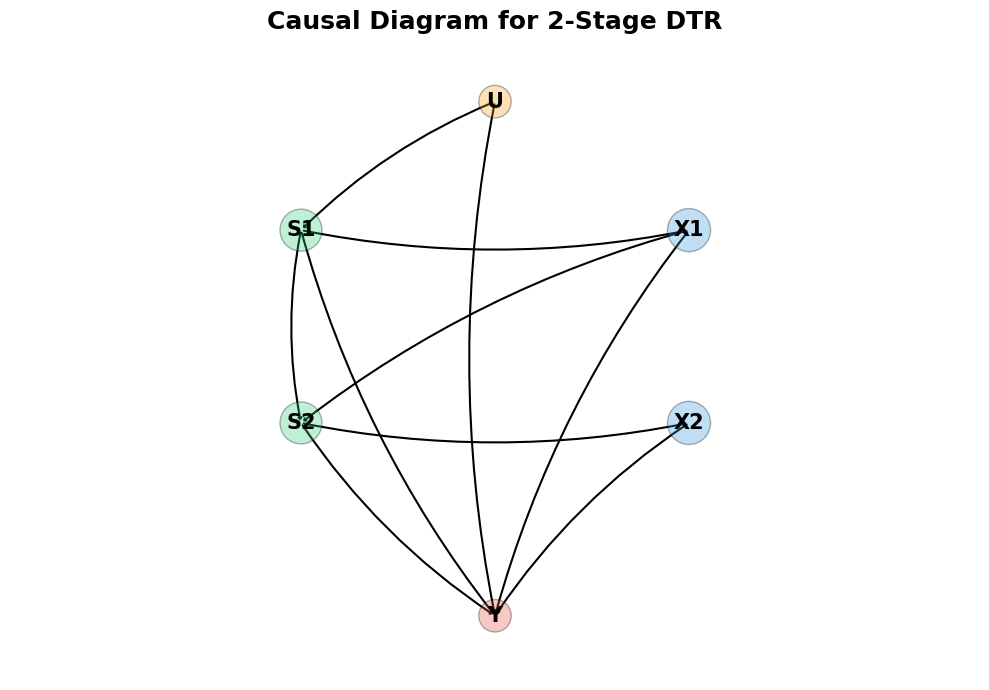

In [32]:
# First, let's create a visualization of the DTR causal diagram
fig, ax = plt.subplots(figsize=(10, 7))

# Define node positions
node_positions = {
    'S1': (0.3, 0.7),
    'X1': (0.7, 0.7),
    'S2': (0.3, 0.4),
    'X2': (0.7, 0.4),
    'Y': (0.5, 0.1),
    'U': (0.5, 0.9)
}

# Draw nodes
for node, pos in node_positions.items():
    if node == 'U':
        color = '#f39c12'  # Yellow for unobserved
        ax.text(pos[0], pos[1], node, ha='center', va='center', fontsize=15,
                fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
    else:
        if node.startswith('X'):
            color = '#3498db'  # Blue for action
        elif node.startswith('S'):
            color = '#2ecc71'  # Green for state
        else:
            color = '#e74c3c'  # Red for reward
        ax.text(pos[0], pos[1], node, ha='center', va='center', fontsize=15,
                fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))

# Draw edges
edges = [
    ('S1', 'X1'),
    ('X1', 'S2'),
    ('S1', 'S2'),
    ('S2', 'X2'),
    ('S1', 'Y'),
    ('X1', 'Y'),
    ('S2', 'Y'),
    ('X2', 'Y'),
    ('U', 'S1'),
    ('U', 'Y')
]

for src, dst in edges:
    arrow = FancyArrowPatch(
        node_positions[src], node_positions[dst],
        connectionstyle='arc3,rad=0.1',
        arrowstyle='->,head_width=1,head_length=1',
        color='black',
        linewidth=1.5
    )
    ax.add_patch(arrow)

ax.set_title("Causal Diagram for 2-Stage DTR", fontsize=18, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plt.tight_layout()
plt.show()

### Explanation of the DTR Planning Problem
In Example 8.6, we have a 2-stage DTR model where:


1. $S_1​$ is the initial patient condition

2. $X_1$​ is the first treatment decision

3. $S_2$​ is the patient's response to the first treatment

4. $X_2$​ is the second treatment decision

5. $Y$ is the final outcome (days of abstinence)


We want to find the optimal treatment policy $p^* = (p_1^*, p_2^*)$ that maximizes the expected outcome $\mathbb{E}_p[Y]$

In [33]:
# Initialize the DTR environment
# We're setting coefficients a1 = a2 = 0 to match Example 8.6
dtr_env = DTRExamplePCH(a1=0, a2=0)

# Let's visualize the optimal policy calculation using dynamic programming
# First, calculate Q(2) values - the value function for the second stage
q2_values = {}

# Compute Q(2) for all state-action combinations
print("Computing Q(2) values for all state-action combinations...")
for s1 in [0, 1]:
    for x1 in [0, 1]:
        for s2 in [0, 1]:
            for x2 in [0, 1]:
                # Estimate the expected reward from observational distribution
                reward_sum = 0
                n_samples = 1000
                for _ in range(n_samples):
                    dtr_env.reset()
                    dtr_env.state = s1
                    _, _, _, _, _ = dtr_env.do(x1)
                    dtr_env.state = s2
                    _, reward, _, _, _ = dtr_env.do(x2)
                    reward_sum += reward
                q2_values[(s1, x1, s2, x2)] = reward_sum / n_samples
                print(f"Q(2)(s1={s1}, x1={x1}, s2={s2}, x2={x2}) = {q2_values[(s1, x1, s2, x2)]:.4f}")

Computing Q(2) values for all state-action combinations...
Q(2)(s1=0, x1=0, s2=0, x2=0) = 0.4900
Q(2)(s1=0, x1=0, s2=0, x2=1) = 0.7400
Q(2)(s1=0, x1=0, s2=1, x2=0) = 0.4950
Q(2)(s1=0, x1=0, s2=1, x2=1) = 0.7220
Q(2)(s1=0, x1=1, s2=0, x2=0) = 0.0000
Q(2)(s1=0, x1=1, s2=0, x2=1) = 0.4910
Q(2)(s1=0, x1=1, s2=1, x2=0) = 0.0000
Q(2)(s1=0, x1=1, s2=1, x2=1) = 0.4960
Q(2)(s1=1, x1=0, s2=0, x2=0) = 0.4970
Q(2)(s1=1, x1=0, s2=0, x2=1) = 0.7360
Q(2)(s1=1, x1=0, s2=1, x2=0) = 0.4910
Q(2)(s1=1, x1=0, s2=1, x2=1) = 0.7350
Q(2)(s1=1, x1=1, s2=0, x2=0) = 0.0000
Q(2)(s1=1, x1=1, s2=0, x2=1) = 0.5080
Q(2)(s1=1, x1=1, s2=1, x2=0) = 0.0000
Q(2)(s1=1, x1=1, s2=1, x2=1) = 0.5170


In [34]:
# Now calculate Q(1) values using Q(2)
q1_values = {}
print("\nComputing Q(1) values for all state-action combinations...")
for s1 in [0, 1]:
    for x1 in [0, 1]:
        # For each s1, x1 combination, find the best x2 for each possible s2
        value = 0
        for s2 in [0, 1]:
            # Probability of s2 given s1, x1
            p_s2_given_s1_x1 = 0
            n_samples = 1000
            count_s2 = 0
            for _ in range(n_samples):
                dtr_env.reset()
                dtr_env.state = s1
                next_state, _, _, _, _ = dtr_env.do(x1)
                if next_state == s2:
                    count_s2 += 1
            p_s2_given_s1_x1 = count_s2 / n_samples
            
            # For a given s2, find the optimal x2
            best_x2_value = max(q2_values[(s1, x1, s2, 0)], q2_values[(s1, x1, s2, 1)])
            
            # Add weighted by transition probability
            value += p_s2_given_s1_x1 * best_x2_value
        
        q1_values[(s1, x1)] = value
        print(f"Q(1)(s1={s1}, x1={x1}) = {q1_values[(s1, x1)]:.4f}")



Computing Q(1) values for all state-action combinations...
Q(1)(s1=0, x1=0) = 0.7553
Q(1)(s1=0, x1=1) = 0.5051
Q(1)(s1=1, x1=0) = 0.7450
Q(1)(s1=1, x1=1) = 0.4916


#### Define the optimal policy based on Q values

In [35]:
# Define the optimal policy based on Q values
def optimal_policy_stage1(s1):
    return 0 if q1_values[(s1, 0)] >= q1_values[(s1, 1)] else 1

def optimal_policy_stage2(s1, x1, s2):
    return 0 if q2_values[(s1, x1, s2, 0)] >= q2_values[(s1, x1, s2, 1)] else 1

In [36]:
# Print the optimal policy
print("\nOptimal Policy:")
print("Stage 1:")
for s1 in [0, 1]:
    print(f"  If S1 = {s1}, then X1 = {optimal_policy_stage1(s1)}")

print("Stage 2:")
for s1 in [0, 1]:
    for x1 in [0, 1]:
        for s2 in [0, 1]:
            print(f"  If S1 = {s1}, X1 = {x1}, S2 = {s2}, then X2 = {optimal_policy_stage2(s1, x1, s2)}")

# Evaluate the expected reward of the optimal policy for a 2 stage dtr environment specifically
def evaluate_optimal_policy():
    rewards = []
    n_samples = 1000
    for _ in range(n_samples):
        dtr_env.reset()
        s1 = dtr_env.state
        x1 = optimal_policy_stage1(s1)
        s2, _, _, _, _ = dtr_env.do(x1)
        x2 = optimal_policy_stage2(s1, x1, s2)
        _, reward, _, _, _ = dtr_env.do(x2)
        rewards.append(reward)
    return np.mean(rewards)

print(f"\nExpected reward of optimal policy: {evaluate_optimal_policy():.4f}")


Optimal Policy:
Stage 1:
  If S1 = 0, then X1 = 0
  If S1 = 1, then X1 = 0
Stage 2:
  If S1 = 0, X1 = 0, S2 = 0, then X2 = 1
  If S1 = 0, X1 = 0, S2 = 1, then X2 = 1
  If S1 = 0, X1 = 1, S2 = 0, then X2 = 1
  If S1 = 0, X1 = 1, S2 = 1, then X2 = 1
  If S1 = 1, X1 = 0, S2 = 0, then X2 = 1
  If S1 = 1, X1 = 0, S2 = 1, then X2 = 1
  If S1 = 1, X1 = 1, S2 = 0, then X2 = 1
  If S1 = 1, X1 = 1, S2 = 1, then X2 = 1

Expected reward of optimal policy: 0.7230


Mathematical Derivation of Dynamic Programming in DTR
For the 2-stage DTR, the dynamic programming approach calculates:
$$
Q^{(2)}_p(s_1, x_1, s_2, x_2) = \mathbb{E}[Y | s_1, x_1, s_2, x_2]\\
Q^{(1)}_p(s_1, x_1) = \sum_{s_2} Q^{(2)}_p(s_1, x_1, s_2, x_2^*) P(s_2 | s_1, x_1)\\
$$
where $x_2^* = \arg\max_{x_2} Q^{(2)}_p(s_1, x_1, s_2, x_2)$


The optimal policy is given by:
$$
p_1^*(s_1) = \arg\max_{x_1} Q^{(1)}_p(s_1, x_1)\\
p_2^*(s_1, x_1, s_2) = \arg\max_{x_2} Q^{(2)}_p(s_1, x_1, s_2, x_2)\\
$$

## The MDP Environment from Example 8.10-8.13

The SCM $M^*$ from the examples is defined as:

$$\begin{align}
M^* = \langle U = \{U_{i,1}, U_{i,2}, U_{i,3}\}, V = \{X_i, Y_i, S_i\}, F, P(U) \rangle_{i=1,2,...}
\end{align}$$

Where the structural functions $F$ are defined as:

$$\begin{align}
F_i = \begin{cases}
S_i \leftarrow (S_{i-1} \vee X_{i-1}) \oplus U_{i-1,1} \oplus U_{i-1,2}, \\
X_i \leftarrow S_i \oplus U_{i,1}, \\
Y_i \leftarrow S_i \oplus X_i \oplus U_{i,1} \oplus U_{i,3}
\end{cases}
\end{align}$$

And $P(U)$ is such that $U_{i,1}, U_{i,2}, U_{i,3}$ are independent variables with:
- $P(U_{i,1} = 1) = 0.9$
- $P(U_{i,2} = 0) = 0.9$
- $P(U_{i,3} = 0) = 0.9$

### Observational and Interventional Distributions

The key insight from these examples is the distinction between observational and interventional distributions:

#### Observational Distribution

The observational distribution $P(V)$ represents the joint probability distribution of the endogenous variables when they evolve naturally according to their structural equations.

For the MDP, this means observing states, actions, and rewards when the actions are determined by the behavior policy (which is encoded in the structural function for $X_i$).

#### Interventional Distribution

The interventional distribution $P_x(Y)$ represents the distribution of variables $Y$ when variables $X$ are forced to take specific values through intervention (denoted as $do(X=x)$).

For the MDP, this means setting the actions directly and observing how states and rewards evolve.

# Example 8.10: MDP Observational vs Interventional Distributions
In this example, we explore the difference between observational and interventional distributions in an MDP environment. The observational distribution relates to what happens when we passively observe the environment, while the interventional distribution relates to what happens when we actively intervene.

## Background: MDP Example from Chapter 7 and 8

We'll be working with the MDP environment described in Equation 7.4 and revisited in Examples 8.10-8.13. This environment has a simple structure: 

- Binary state $S_i \in \{0, 1\}$
- Binary action $X_i \in \{0, 1\}$
- Binary reward $Y_i \in \{0, 1\}$
- Exogenous variables $U_{i,1}, U_{i,2}, U_{i,3} \in \{0, 1\}$

The causal mechanisms in the SCM are defined as:

$$
\begin{align}
S_i &\leftarrow (S_{i-1} \vee X_{i-1}) \oplus U_{i-1,1} \oplus U_{i-1,2} \\
X_i &\leftarrow S_i \oplus U_{i,1} \\
Y_i &\leftarrow S_i \oplus X_i \oplus U_{i,1} \oplus U_{i,3}
\end{align}
$$

Where $\oplus$ represents the XOR operation (exclusive OR) and $\vee$ represents the OR operation.

The exogenous variables $U_{i,1}, U_{i,2}, U_{i,3}$ are independent binary variables with:
- $P(U_{i,1} = 1) = 0.9$
- $P(U_{i,2} = 0) = 0.9$
- $P(U_{i,3} = 0) = 0.9$

Our goal is to explore different aspects of this MDP model through observational and interventional distributions, and to understand how this relates to policy learning.

## Example 8.10: Observational Distribution in an MDP

Example 8.10 demonstrates that when learning from observational data in an MDP, we get a specific optimal policy that might not match the true optimal policy.

Let's derive the transition probabilities and expected rewards:

For transition probability $P(S_{i+1} | S_i, X_i)$:

$$\begin{align}
P(S_{i+1} | S_i = s, X_i = x) &= P((s \vee x) \oplus U_{i,1} \oplus U_{i,2} | S_i = s, X_i = x) \\
&= P((s \vee x) \oplus U_{i,1} \oplus U_{i,2})
\end{align}$$

For expected reward $\mathbb{E}[Y_i | S_i, X_i]$:

$$\begin{align}
\mathbb{E}[Y_i | S_i = s, X_i = x] &= \mathbb{E}[s \oplus x \oplus U_{i,1} \oplus U_{i,3} | S_i = s, X_i = x] \\
&= \mathbb{E}[s \oplus x \oplus U_{i,1} \oplus U_{i,3}]
\end{align}$$

Let's first collect observational data from our MDP environment:

In [37]:
# Collect observational data
obs_data = collect_observational_data_mdp(n_samples=N_SAMPLES, MAX_STEPS=MAX_STEPS)

# Extract transition probabilities and expected rewards
obs_transition_probs = obs_data['transition_probs']
obs_expected_rewards = obs_data['expected_rewards']
obs_counts = obs_data['counts']

# Print the observational distribution
print("Observational Distribution:")
print("==========================")
print("\nTransition Probabilities P(S_{i+1} | S_i, X_i):")
for s in range(2):
    for x in range(2):
        for next_s in range(2):
            print(f"P(S_{i+1}={next_s} | S_i={s}, X_i={x}) = {obs_transition_probs[s, x, next_s]:.4f}")

print("\nExpected Rewards E[Y_i | S_i, X_i]:")
for s in range(2):
    for x in range(2):
        print(f"E[Y_i | S_i={s}, X_i={x}] = {obs_expected_rewards[s, x]:.4f}")

print("\nCounts (number of samples for each state-action pair):")
for s in range(2):
    for x in range(2):
        print(f"Count(S={s}, X={x}) = {int(obs_counts[s, x])}")

Observational Distribution:

Transition Probabilities P(S_{i+1} | S_i, X_i):
P(S_2000=0 | S_i=0, X_i=0) = 0.0994
P(S_2000=1 | S_i=0, X_i=0) = 0.0994
P(S_2000=0 | S_i=0, X_i=1) = 0.0992
P(S_2000=1 | S_i=0, X_i=1) = 0.0992
P(S_2000=0 | S_i=1, X_i=0) = 0.6806
P(S_2000=1 | S_i=1, X_i=0) = 0.6806
P(S_2000=0 | S_i=1, X_i=1) = 0.9097
P(S_2000=1 | S_i=1, X_i=1) = 0.9097

Expected Rewards E[Y_i | S_i, X_i]:
E[Y_i | S_i=0, X_i=0] = 0.1007
E[Y_i | S_i=0, X_i=1] = 0.1008
E[Y_i | S_i=1, X_i=0] = 0.0921
E[Y_i | S_i=1, X_i=1] = 0.0998

Counts (number of samples for each state-action pair):
Count(S=0, X=0) = 19661
Count(S=0, X=1) = 20456
Count(S=1, X=0) = 3096
Count(S=1, X=1) = 2315


Now let's compute the optimal Q-function based on the observational distribution using value iteration:

In [38]:
def value_iteration(transition_probs, rewards, gamma=0.9, theta=1e-6):
    """
    Perform value iteration to compute optimal Q-values.
    
    Args:
        transition_probs: Transition probabilities P(s'|s,a)
        rewards: Expected rewards R(s,a)
        gamma: Discount factor
        theta: Convergence threshold
        
    Returns:
        Q: Optimal state-action value function
    """
    # Initialize Q-values
    Q = np.zeros((2, 2))
    
    while True:
        delta = 0
        # Update Q-values
        for s in range(2):
            for a in range(2):
                q_old = Q[s, a]
                
                # Calculate the expected value of taking action a in state s
                expected_value = 0
                for next_s in range(2):
                    # Q(s,a) = R(s,a) + gamma * sum_s'[ P(s'|s,a) * max_a'[ Q(s',a') ] ]
                    expected_value += transition_probs[s, a, next_s] * np.max(Q[next_s])
                
                Q[s, a] = rewards[s, a] + gamma * expected_value
                
                # Update maximum change
                delta = max(delta, abs(q_old - Q[s, a]))
        
        # Check convergence
        if delta < theta:
            break
    
    return Q

In [39]:
# Compute optimal Q-function based on observational data
q_star_obs = value_iteration(obs_transition_probs, obs_expected_rewards, gamma=GAMMA)

# Derive optimal policy
optimal_policy_obs = np.argmax(q_star_obs, axis=1)

print("Optimal Q-function (Observational):")
print("==================================")
for s in range(2):
    for a in range(2):
        print(f"Q*(S={s}, X={a}) = {q_star_obs[s, a]:.4f}")

print("\nOptimal Policy (Observational):")
for s in range(2):
    print(f"π*(S={s}) = {optimal_policy_obs[s]}")

Optimal Q-function (Observational):
Q*(S=0, X=0) = 0.2959
Q*(S=0, X=1) = 0.2957
Q*(S=1, X=0) = 1.4293
Q*(S=1, X=1) = 1.8873

Optimal Policy (Observational):
π*(S=0) = 0
π*(S=1) = 1


As described in Example 8.10, the optimal policy from observational data is:
- For state s=0: Choose action X=1
- For state s=1: Choose action X=0

This means the policy is $\pi^*_{\text{obs}} \approx X_i \leftarrow \neg S_i$ (where $\neg$ represents negation).

## Example 8.11: Interventional Distribution in an MDP

Example 8.11 shows how the interventional distribution differs from the observational distribution, leading to a different optimal policy.

In Example 8.11, we analyze the interventional distribution of the MDP. This represents the dynamics when actions are set through interventions, bypassing the structural equation for $X_i$.

Let's derive the transition probabilities and expected rewards under intervention:

For transition probability $P(S_{i+1} | do(X_i = x), S_i = s)$:

$$\begin{align}
P(S_{i+1} | do(X_i = x), S_i = s) &= P((s \vee x) \oplus U_{i,1} \oplus U_{i,2} | S_i = s) \\
&= \sum_{u1} \sum_{u2} P((s \vee x) \oplus u1 \oplus u2) P(U_{i,1} = u1) P(U_{i,2} = u2)
\end{align}$$

For expected reward $\mathbb{E}[Y_i | do(X_i = x), S_i = s]$:

$$\begin{align}
\mathbb{E}[Y_i | do(X_i = x), S_i = s] &= \mathbb{E}[s \oplus x \oplus U_{i,1} \oplus U_{i,3} | S_i = s] \\
&= \sum_{u1} \sum_{u3} (s \oplus x \oplus u1 \oplus u3) P(U_{i,1} = u1) P(U_{i,3} = u3)
\end{align}$$

Now, let's solve for the optimal policy using the interventional distribution:

In [40]:
# Collect interventional data (do-operator)
int_data = collect_interventional_data_mdp(n_samples=N_SAMPLES, MAX_STEPS=MAX_STEPS)

# Extract transition probabilities and expected rewards
int_transition_probs = int_data['transition_probs']
int_expected_rewards = int_data['expected_rewards']
int_counts = int_data['counts']

# Print the interventional distribution
print("Interventional Distribution:")
print("===========================")
print("\nTransition Probabilities P(S_{i+1} | S_i, do(X_i)):")
for s in range(2):
    for x in range(2):
        for next_s in range(2):
            print(f"P(S_{i+1}={next_s} | S_i={s}, do(X_i={x})) = {int_transition_probs[s, x, next_s]:.4f}")

print("\nExpected Rewards E[Y_i | S_i, do(X_i)]:")
for s in range(2):
    for x in range(2):
        print(f"E[Y_i | S_i={s}, do(X_i={x})] = {int_expected_rewards[s, x]:.4f}")

print("\nCounts (number of samples for each state-action pair):")
for s in range(2):
    for x in range(2):
        print(f"Count(S={s}, X={x}) = {int_counts[s, x]}")

# Compute optimal Q-function based on interventional data
q_star_int = value_iteration(int_transition_probs, int_expected_rewards, gamma=GAMMA)

# Derive optimal policy
optimal_policy_int = np.argmax(q_star_int, axis=1)

print("\nOptimal Q-function (Interventional):")
print("==================================")
for s in range(2):
    for a in range(2):
        print(f"Q*(S={s}, X={a}) = {q_star_int[s, a]:.4f}")

print("\nOptimal Policy (Interventional):")
for s in range(2):
    print(f"π*(S={s}) = {optimal_policy_int[s]}")

Interventional Distribution:

Transition Probabilities P(S_{i+1} | S_i, do(X_i)):
P(S_2000=0 | S_i=0, do(X_i=0)) = 0.8230
P(S_2000=1 | S_i=0, do(X_i=0)) = 0.8230
P(S_2000=0 | S_i=0, do(X_i=1)) = 0.1770
P(S_2000=1 | S_i=0, do(X_i=1)) = 0.1770
P(S_2000=0 | S_i=1, do(X_i=0)) = 0.1940
P(S_2000=1 | S_i=1, do(X_i=0)) = 0.1940
P(S_2000=0 | S_i=1, do(X_i=1)) = 0.1940
P(S_2000=1 | S_i=1, do(X_i=1)) = 0.1940

Expected Rewards E[Y_i | S_i, do(X_i)]:
E[Y_i | S_i=0, do(X_i=0)] = 0.8210
E[Y_i | S_i=0, do(X_i=1)] = 0.1790
E[Y_i | S_i=1, do(X_i=0)] = 0.1810
E[Y_i | S_i=1, do(X_i=1)] = 0.8190

Counts (number of samples for each state-action pair):
Count(S=0, X=0) = 2000.0
Count(S=0, X=1) = 2000.0
Count(S=1, X=0) = 2000.0
Count(S=1, X=1) = 2000.0

Optimal Q-function (Interventional):
Q*(S=0, X=0) = 15.1628
Q*(S=0, X=1) = 3.2634
Q*(S=1, X=0) = 3.5617
Q*(S=1, X=1) = 4.1997

Optimal Policy (Interventional):
π*(S=0) = 0
π*(S=1) = 1


From the interventional data, we get a different optimal policy:
- For state s=0: Choose action X=0
- For state s=1: Choose action X=1

This means the policy is $\pi^*_{\text{exp}} \approx X_i \leftarrow S_i$ (the agent's action matches the state).

According to Example 8.11, the interventional distribution leads us to the true optimal policy in the underlying environment, which is $\pi^*_{\text{exp}} \approx X_i \leftarrow S_i$. This policy yields a higher expected reward when deployed in the actual environment, as shown in the Q-values.

This difference between the observational and interventional distributions demonstrates that just observing an environment without actively experimenting in it can lead to suboptimal policies.



## Example 8.12: Observational ≠⇒ Interventional

Example 8.12 introduces an alternative MDP environment (denoted as $M^{(1)}$) that generates the same observational distribution as the original environment ($M^*$) but has a different interventional distribution.

The alternative MDP has causal mechanisms defined as:

$
\begin{align}
S_i &\leftarrow S_{i-1} \oplus U_{i-1,2} \\
X_i &\leftarrow S_i \oplus U_{i,1} \\
Y_i &\leftarrow U_{i,3}
\end{align}
$



Example 8.12 illustrates that the observational distribution does not uniquely determine the interventional distribution. In other words, there can be different SCMs that generate the same observational distributions but different interventional ones.
Let's visualize the difference between the two distributions:

In [41]:
# Create MDP visualization for observational and interventional distributions
def visualize_mdp_transitions(transition_probs, rewards, title):
    """
    Visualize MDP transitions and rewards as a graph
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Position the states
    pos = {
        "S=0": (0, 0),
        "S=1": (3, 0)
    }
    
    # Draw the states as nodes
    for state, position in pos.items():
        circle = plt.Circle(position, 0.5, fc='lightblue', ec='black')
        ax.add_artist(circle)
        ax.text(position[0], position[1], state, ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Draw the transitions as arrows
    for s in range(2):
        for a in range(2):
            for next_s in range(2):
                # Skip very low probability transitions
                if transition_probs[s, a, next_s] < 0.01:
                    continue
                
                start_pos = pos[f"S={s}"]
                end_pos = pos[f"S={next_s}"]
                
                # Determine curvature based on action and self-loop
                if s == next_s:
                    # Self-loop
                    if a == 0:
                        # Action 0 curves upward
                        ax.annotate("", 
                                   xy=(start_pos[0], start_pos[1]+0.6), 
                                   xytext=(start_pos[0], start_pos[1]+0.6),
                                   arrowprops=dict(arrowstyle="->", 
                                                  connectionstyle="arc3,rad=0.5",
                                                  color='blue' if a == 0 else 'red',
                                                  lw=2))
                        # Add label
                        ax.text(start_pos[0], start_pos[1]+0.8, 
                                f"X={a}\n{transition_probs[s, a, next_s]:.2f}, Y={rewards[s, a]:.2f}",
                                ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7))
                    else:
                        # Action 1 curves downward
                        ax.annotate("", 
                                   xy=(start_pos[0], start_pos[1]-0.6), 
                                   xytext=(start_pos[0], start_pos[1]-0.6),
                                   arrowprops=dict(arrowstyle="->", 
                                                  connectionstyle="arc3,rad=0.5",
                                                  color='blue' if a == 0 else 'red',
                                                  lw=2))
                        # Add label
                        ax.text(start_pos[0], start_pos[1]-0.8, 
                                f"X={a}\n{transition_probs[s, a, next_s]:.2f}, Y={rewards[s, a]:.2f}",
                                ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7))
                else:
                    # Transition to different state
                    if a == 0:
                        # Action 0 curves upward
                        ax.annotate("", 
                                   xy=end_pos, 
                                   xytext=start_pos,
                                   arrowprops=dict(arrowstyle="->", 
                                                  connectionstyle="arc3,rad=0.3",
                                                  color='blue',
                                                  lw=2))
                        # Add label at midpoint with slight upward offset
                        midpoint = ((start_pos[0] + end_pos[0])/2, (start_pos[1] + end_pos[1])/2 + 0.3)
                        ax.text(midpoint[0], midpoint[1], 
                                f"X={a}\n{transition_probs[s, a, next_s]:.2f}, Y={rewards[s, a]:.2f}",
                                ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7))
                    else:
                        # Action 1 curves downward
                        ax.annotate("", 
                                   xy=end_pos, 
                                   xytext=start_pos,
                                   arrowprops=dict(arrowstyle="->", 
                                                  connectionstyle="arc3,rad=-0.3",
                                                  color='red',
                                                  lw=2))
                        # Add label at midpoint with slight downward offset
                        midpoint = ((start_pos[0] + end_pos[0])/2, (start_pos[1] + end_pos[1])/2 - 0.3)
                        ax.text(midpoint[0], midpoint[1], 
                                f"X={a}\n{transition_probs[s, a, next_s]:.2f}, Y={rewards[s, a]:.2f}",
                                ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7))
    
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    ax.axis('off')
    
    return fig

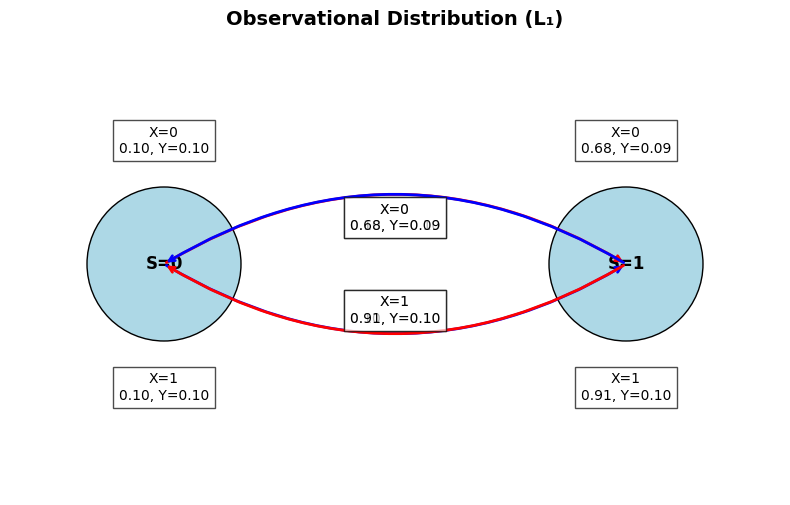

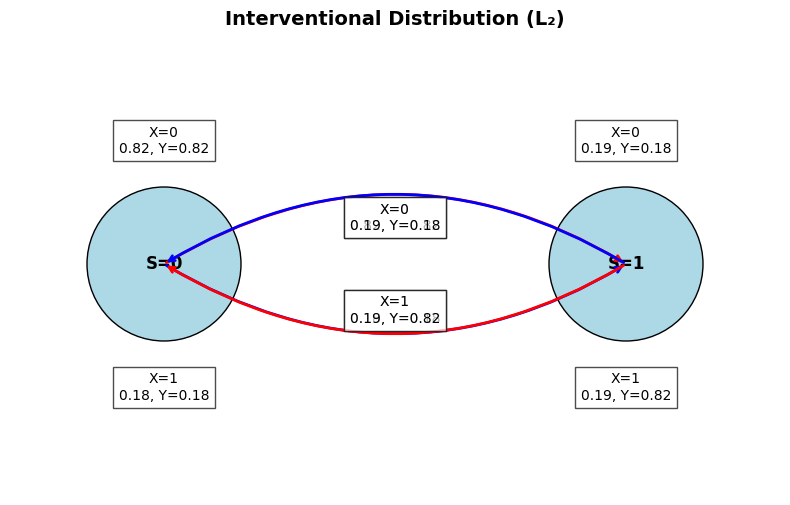


Same Observational ≠> Same Interventional Distribution
-----------------------------------------------------
The observational distribution underdetermines the interventional distribution.
This means there can be multiple SCMs that generate the same L₁ distribution
but different L₂ distributions.


In [42]:
# Visualize the observational distribution
fig_obs = visualize_mdp_transitions(obs_transition_probs, obs_expected_rewards, 
                                  "Observational Distribution (L₁)")
plt.show()

# Visualize the interventional distribution
fig_int = visualize_mdp_transitions(int_transition_probs, int_expected_rewards, 
                                  "Interventional Distribution (L₂)")
plt.show()

# Alternate SCM M(1) with same observational but different interventional distribution
print("\nSame Observational ≠> Same Interventional Distribution")
print("-----------------------------------------------------")
print("The observational distribution underdetermines the interventional distribution.")
print("This means there can be multiple SCMs that generate the same L₁ distribution")
print("but different L₂ distributions.")

The key insight from Example 8.12 is that the observational distribution of an MDP is generally insufficient to uniquely determine the interventional distribution. This means that even with unlimited observational data, we cannot always infer how the environment will respond to our interventions.

Proposition 8.1.1 in the textbook formalizes this insight: For any SCM $M^*$ compatible with the causal diagram of an MDP, there exists another SCM $M^{(1)}$ that generates the same observational distribution but a different interventional distribution.

## Example 8.13: Interventional ≠⇒ Observational

Example 8.13 presents another alternative MDP environment (denoted as $M^{(2)}$) that has the same interventional distribution as the original environment ($M^*$) but a different observational distribution.

The causal mechanisms for $M^{(2)}$ are:

$
\begin{align}
S_i &\leftarrow (S_{i-1} \vee X_{i-1}) \oplus U_{i-1,2} \\
X_i &\leftarrow S_i \oplus U_{i,1} \\
Y_i &\leftarrow S_i \oplus X_i \oplus U_{i,3}
\end{align}
$

Example 8.13 complements Example 8.12 by illustrating that the interventional distribution also does not uniquely determine the observational distribution.

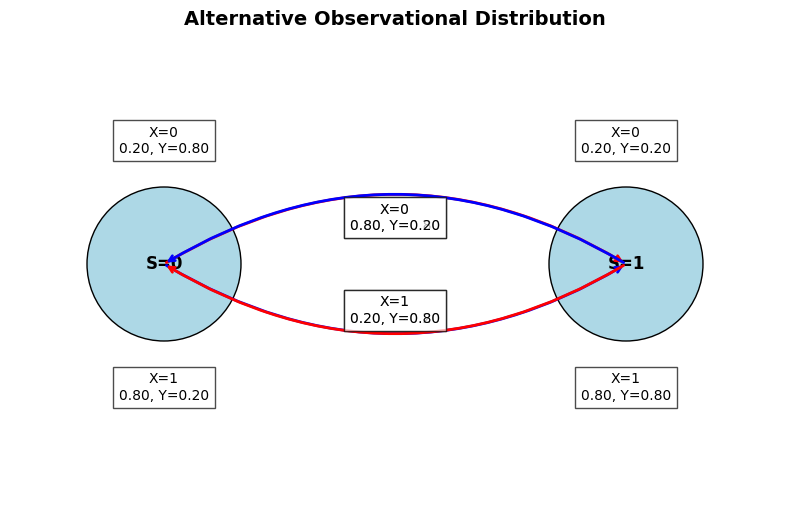


Same Interventional ≠> Same Observational Distribution
-----------------------------------------------------
The interventional distribution underdetermines the observational distribution.
This means there can be multiple SCMs that generate the same L₂ distribution
but different L₁ distributions.


In [43]:
# Demonstrate with another hypothetical model M(2) with same interventional but different observational

# Let's generate synthetic data for an alternate model with same L₂ but different L₁
# For simplicity, we'll use the actual interventional data but modify the observational data
alt_obs_transition_probs = np.zeros_like(obs_transition_probs)
alt_obs_expected_rewards = np.zeros_like(obs_expected_rewards)

# Create hypothetical observational data different from our actual data
# but that would produce the same interventional data
alt_obs_transition_probs[0, 0, 0] = 0.2
alt_obs_transition_probs[0, 0, 1] = 0.8
alt_obs_transition_probs[0, 1, 0] = 0.8
alt_obs_transition_probs[0, 1, 1] = 0.2
alt_obs_transition_probs[1, 0, 0] = 0.8
alt_obs_transition_probs[1, 0, 1] = 0.2
alt_obs_transition_probs[1, 1, 0] = 0.2
alt_obs_transition_probs[1, 1, 1] = 0.8

alt_obs_expected_rewards[0, 0] = 0.8
alt_obs_expected_rewards[0, 1] = 0.2
alt_obs_expected_rewards[1, 0] = 0.2
alt_obs_expected_rewards[1, 1] = 0.8

# Visualize this alternate observational model
fig_alt_obs = visualize_mdp_transitions(alt_obs_transition_probs, alt_obs_expected_rewards, 
                                      "Alternative Observational Distribution")
plt.show()

print("\nSame Interventional ≠> Same Observational Distribution")
print("-----------------------------------------------------")
print("The interventional distribution underdetermines the observational distribution.")
print("This means there can be multiple SCMs that generate the same L₂ distribution")
print("but different L₁ distributions.")

## Policy Evaluation in Different Models

Let's evaluate different policies in both the observational and interventional models to demonstrate the differences:

In [44]:
# Define policies for evaluation
policies = [
    {"policy": always_zero_policy, "name": "Always X=0"},
    {"policy": always_one_policy, "name": "Always X=1"},
    {"policy": match_state_policy, "name": "X=S (Match state)"},
    {"policy": opposite_state_policy, "name": "X≠S (Opposite state)"}
]

# Evaluate each policy
print("\nPolicy Evaluation Results:")
print("========================")

# Define function to evaluate policy using DP algorithm
def evaluate_policy_dp(policy, transition_probs, rewards, gamma=0.9):
    """
    Evaluate a policy using dynamic programming (DP) algorithm.
    
    Args:
        policy: Function mapping state to action
        transition_probs: Transition probabilities P(s'|s,a)
        rewards: Expected rewards R(s,a)
        gamma: Discount factor
        
    Returns:
        value: Expected discounted return
    """
    # Initialize value function
    value = np.zeros(2)  # for two states
    
    # Create policy matrix (state -> action)
    policy_matrix = np.array([policy(s) for s in range(2)])
    
    # Policy evaluation
    delta = 1
    while delta > 1e-6:
        delta = 0
        for s in range(2):
            v = value[s]
            a = policy_matrix[s]
            
            # Calculate expected value for this state
            value[s] = rewards[s, a]
            for next_s in range(2):
                value[s] += gamma * transition_probs[s, a, next_s] * value[next_s]
            
            delta = max(delta, abs(v - value[s]))
    
    # Return expected return (weighted average of state values)
    # Assuming uniform initial state distribution
    return np.mean(value)

# Evaluate policies using both observational and interventional data
print("\nUsing Dynamic Programming (DP):")
print("==============================")
for policy_info in policies:
    policy = policy_info["policy"]
    name = policy_info["name"]
    
    # Evaluate using observational data
    value_obs = evaluate_policy_dp(policy, obs_transition_probs, obs_expected_rewards, GAMMA)
    
    # Evaluate using interventional data
    value_int = evaluate_policy_dp(policy, int_transition_probs, int_expected_rewards, GAMMA)
    
    print(f"Policy: {name}")
    print(f"  Value (Observational Model): {value_obs:.4f}")
    print(f"  Value (Interventional Model): {value_int:.4f}")
    print(f"  Difference: {abs(value_obs - value_int):.4f}")
    print("")

# Evaluate policies using direct simulation (more accurate)
print("\nUsing Direct Simulation:")
print("======================")
for policy_info in policies:
    policy = policy_info["policy"]
    name = policy_info["name"]
    
    result = evaluate_policy(policy, name, N_SAMPLES=1000)
    print(f"Policy: {name}")
    print(f"  Expected Reward: {result['mean_reward']:.4f}")
    print(f"  Daily Profit: {result['daily_profit']:.4f}")
    print("")

# Compare the optimal policies derived from observational vs interventional data
print("\nOptimal Policy Comparison:")
print("========================")
print(f"Optimal policy from observational data: S=0 → X={optimal_policy_obs[0]}, S=1 → X={optimal_policy_obs[1]}")
print(f"Optimal policy from interventional data: S=0 → X={optimal_policy_int[0]}, S=1 → X={optimal_policy_int[1]}")


Policy Evaluation Results:

Using Dynamic Programming (DP):
Policy: Always X=0
  Value (Observational Model): 0.2082
  Value (Interventional Model): 1.2335
  Difference: 1.0253

Policy: Always X=1
  Value (Observational Model): 0.2715
  Value (Interventional Model): 0.7057
  Difference: 0.4342

Policy: X=S (Match state)
  Value (Observational Model): 0.2715
  Value (Interventional Model): 2.0026
  Difference: 1.7311

Policy: X≠S (Opposite state)
  Value (Observational Model): 0.2083
  Value (Interventional Model): 0.2567
  Difference: 0.0484


Using Direct Simulation:


Evaluating Always X=0: 100%|██████████| 1000/1000 [00:01<00:00, 769.61it/s]


Policy: Always X=0
  Expected Reward: 4.9791
  Daily Profit: 0.5001



Evaluating Always X=1: 100%|██████████| 1000/1000 [00:01<00:00, 995.71it/s]


Policy: Always X=1
  Expected Reward: 3.0452
  Daily Profit: 0.2952



Evaluating X=S (Match state): 100%|██████████| 1000/1000 [00:00<00:00, 1052.34it/s]


Policy: X=S (Match state)
  Expected Reward: 8.1424
  Daily Profit: 0.8200



Evaluating X≠S (Opposite state): 100%|██████████| 1000/1000 [00:01<00:00, 939.51it/s]


Policy: X≠S (Opposite state)
  Expected Reward: 1.8576
  Daily Profit: 0.1800


Optimal Policy Comparison:
Optimal policy from observational data: S=0 → X=0, S=1 → X=1
Optimal policy from interventional data: S=0 → X=0, S=1 → X=1


## Key Insights from Examples 8.10-8.13

The key insight from Example 8.13 is the converse of Example 8.12: the interventional distribution does not uniquely determine the observational distribution. This means that even with unlimited interventional data, we cannot always infer how the environment behaves under the natural policy.

Proposition 8.1.2 in the textbook formalizes this insight: For any SCM $M^*$ compatible with the causal diagram of an MDP, there exists another SCM $M^{(2)}$ that generates the same interventional distribution but a different observational distribution.


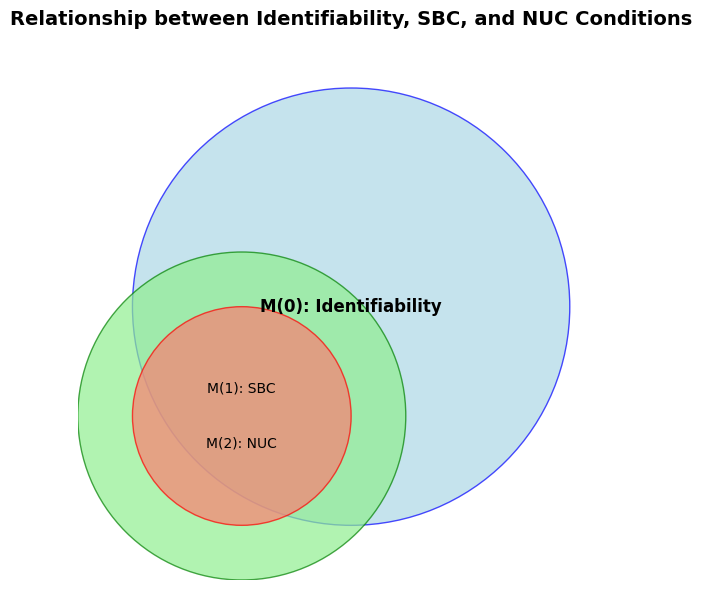


Key Insights from Examples 8.10-8.13:
1. The observational distribution (L₁) does not uniquely determine
   the interventional distribution (L₂), and vice versa.
2. Different SCMs can generate the same L₁ distribution but
   different L₂ distributions (Example 8.12).
3. Different SCMs can generate the same L₂ distribution but
   different L₁ distributions (Example 8.13).
4. This means the optimal policies derived from observational data
   may differ from those derived from interventional data.
5. These examples illustrate the Causal Hierarchy Theorem in MDPs,
   showing that inferences cannot be made across layers of the hierarchy.


In [45]:
# Create visualization to summarize the Causal Hierarchy Theorem in MDP environments
fig, ax = plt.subplots(figsize=(10, 6))

# Draw three overlapping circles
circle1 = plt.Circle((0.5, 0.5), 0.4, fc='lightblue', ec='blue', alpha=0.7)
circle2 = plt.Circle((0.3, 0.3), 0.3, fc='lightgreen', ec='green', alpha=0.7)
circle3 = plt.Circle((0.3, 0.3), 0.2, fc='salmon', ec='red', alpha=0.7)

ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)

# Add labels
ax.text(0.5, 0.5, "M(0): Identifiability", ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(0.3, 0.35, "M(1): SBC", ha='center', va='center', fontsize=10)
ax.text(0.3, 0.25, "M(2): NUC", ha='center', va='center', fontsize=10)

# Set limits and aspect
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')

plt.title("Relationship between Identifiability, SBC, and NUC Conditions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary of key insights
print("\nKey Insights from Examples 8.10-8.13:")
print("===================================")
print("1. The observational distribution (L₁) does not uniquely determine")
print("   the interventional distribution (L₂), and vice versa.")
print("2. Different SCMs can generate the same L₁ distribution but")
print("   different L₂ distributions (Example 8.12).")
print("3. Different SCMs can generate the same L₂ distribution but")
print("   different L₁ distributions (Example 8.13).")
print("4. This means the optimal policies derived from observational data")
print("   may differ from those derived from interventional data.")
print("5. These examples illustrate the Causal Hierarchy Theorem in MDPs,")
print("   showing that inferences cannot be made across layers of the hierarchy.")


## Implications for Reinforcement Learning

These examples (8.10-8.13) provide important insights for reinforcement learning:

1. **Observational vs. Interventional Learning**: Learning from purely observational data (off-policy learning) may lead to suboptimal policies compared to learning from interventional data (online learning).

2. **The Causal Hierarchy Theorem in RL**: The relationship between observational and interventional distributions in RL is a manifestation of the Causal Hierarchy Theorem (from Chapter 2). The impossibility results show that there's a strict separation between Layer 1 (observational) and Layer 2 (interventional) of the Pearl Causal Hierarchy.

3. **Need for Causal Knowledge**: Without additional causal knowledge or assumptions about the environment, we cannot generally bridge the gap between observational and interventional distributions.

4. **Structural Causal Models**: The SCM framework provides a more expressive language for describing RL environments compared to standard MDPs, allowing us to reason about different layers of the causal hierarchy.

Let's visualize the relationships between different SCMs and the PCH layers:

## Conclusion

The examples we've implemented illustrate the fundamental challenge in reinforcement learning: the gap between observational and interventional distributions. This gap is a manifestation of the Causal Hierarchy Theorem, which states that higher layers of causal knowledge cannot generally be obtained from lower layers without additional assumptions.

Standard MDP approaches often implicitly assume access to interventional data or make assumptions that bridge this gap. By using the formalism of Structural Causal Models, we can more explicitly reason about these different layers of causal information and develop algorithms that appropriately account for the available information.

This highlights the importance of causal reasoning in reinforcement learning and motivates the development of Causal Reinforcement Learning methods that explicitly consider the causal structure of the environment.